Quick analysis: Based off of my findings, I think UVA should focues on entering the Qatar donationan network and consider consider spotlighting their research endeavors more. UVA's top donators are Bangladesh, Sweden, Tanzania by amount, while the tope donators are Qatart, United Arab Emirates, and Bermuda. The foundations who donate the most seem to be related to research, while UVA's top donatoins are from educational foundations. Lastly, UVA could consider prioritizing contracts because contract amounts tend to be higher than monetary gifts.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


### Brainstorm
- already know top countries donating: Qatar, Bermuda, United Arab Emirates, Canda, India, Hong Kong, England, China, Australia, France, Singapore, Saudi Arabia, Russia
- VA schools being donated by top countries: VCU (Qatar), Georgetown (Qatar)

### exploring
- who is already donating to VA
- how much
- average/median amount

In [2]:
uva_df = df[df["Institution Name"] == "University of Virginia"]
uva_df

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,41822,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,41870,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,41873,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,41887,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,41904,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd
...,...,...,...,...,...,...,...,...,...,...
26328,26329,374500,University of Virginia,Charlottesville,VA,43602,99885,Contract,SWEDEN,AutoLiv Development AB
26329,26330,374500,University of Virginia,Charlottesville,VA,43697,1000000,Monetary Gift,SWITZERLAND,Lawrence D & Karin S Howell
26330,26331,374500,University of Virginia,Charlottesville,VA,43796,500000,Monetary Gift,GUERNSEY,Harvest Group Holding (PTC Limited)
26331,26332,374500,University of Virginia,Charlottesville,VA,43803,146810,Contract,THE NETHERLANDS,Pantarhei Oncology BV


In [3]:
uva_df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False)

Country of Giftor
BANGLADESH         4228589
SWEDEN             4007552
TANZANIA           2776447
SWITZERLAND        2000000
ENGLAND            1950666
GUERNSEY           1500000
FINLAND            1008384
BERMUDA             900000
KOREA               862787
SINGAPORE           805000
THE NETHERLANDS     725670
ISRAEL              623655
RWANDA              284135
JAPAN               265970
FRANCE              250383
Name: Foreign Gift Amount, dtype: int64

Bangladesh, Sweden, Tanzania, Switzerland, and England are our top 5 giftors by dollar amount

In [4]:
uva_df.groupby("Country of Giftor")["Foreign Gift Amount"].size().sort_values(ascending=False)

Country of Giftor
ENGLAND            31
ISRAEL             12
BANGLADESH         10
SWEDEN             10
FINLAND             7
KOREA               6
FRANCE              5
THE NETHERLANDS     4
GUERNSEY            3
TANZANIA            3
SINGAPORE           2
SWITZERLAND         2
BERMUDA             1
RWANDA              1
JAPAN               1
Name: Foreign Gift Amount, dtype: int64

England, Israel, Bangladesh, Sweden, and Finland are our top 5 giftors by count

In [5]:
giftors = uva_df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending=False)
avg = giftors.mean()
med = giftors.median()

print("avg: ", avg)
print("med: ", med)

avg:  1479282.5333333334
med:  900000.0


In [31]:
uva_df["Gift Type"].value_counts()

Gift Type
Contract         64
Monetary Gift    34
Name: count, dtype: int64

The average for all the universities is 52202878.974842764 vs UVA's 1479282.5333333334. The median for all the universities is 6486791.5 vs UVA's 900000.0. UVA's giftors amount is low compared to the collectives.

In [34]:
print(uva_df.groupby("Gift Type")["Foreign Gift Amount"].mean())
print(uva_df.groupby("Gift Type")["Foreign Gift Amount"].median())

Gift Type
Contract         231369.312500
Monetary Gift    217105.941176
Name: Foreign Gift Amount, dtype: float64
Gift Type
Contract         92130.5
Monetary Gift    67271.5
Name: Foreign Gift Amount, dtype: float64


### Looking at how UVA compares to other VA schools

In [6]:
VA_schools = df[df["State"]=="VA"]
VA_schools.groupby("Institution Name").size()

Institution Name
College of William & Mary                             17
George Mason University                               38
University of Virginia                                98
Virginia Commonwealth University                     115
Virginia Polytechnic Institute & State University     24
dtype: int64

By gift count, UVA has the second most donations behind VCU (who is in the top 20)

In [7]:
VA_schools.groupby("Institution Name")["Foreign Gift Amount"].sum().sort_values(ascending=False)

Institution Name
Virginia Commonwealth University                     89163583
George Mason University                              65435604
University of Virginia                               22189238
Virginia Polytechnic Institute & State University    11792062
College of William & Mary                             3384498
Name: Foreign Gift Amount, dtype: int64

By total gift amount, UVA is actually 3rd behind VCU and George Mason despite GMU receiving less than half of UVAs amount of gifts. Comparatively, UVA gifts might be of smaller quantity. 

In [8]:
VA_schools.groupby("Institution Name")["Foreign Gift Amount"].mean().sort_values(ascending=False)

Institution Name
George Mason University                              1.721990e+06
Virginia Commonwealth University                     7.753355e+05
Virginia Polytechnic Institute & State University    4.913359e+05
University of Virginia                               2.264208e+05
College of William & Mary                            1.990881e+05
Name: Foreign Gift Amount, dtype: float64

In [9]:
VA_schools.groupby("Institution Name")["Foreign Gift Amount"].median().sort_values(ascending=False)

Institution Name
George Mason University                              507053.5
Virginia Polytechnic Institute & State University    350000.0
University of Virginia                                80535.5
College of William & Mary                             51600.0
Virginia Commonwealth University                      33750.0
Name: Foreign Gift Amount, dtype: float64

On average, UVA gift amount is 4th behind GMU, VCU, and VT, showing the average gift amount is much lower comapred to other VA schools
BUT, when taking the median, UVA is 3rd behind GMU and VT. VCU is actually last, so there must have been some large donations skewing the data. 

I wonder what the donations look like for each school.

In [10]:
VA_schools.groupby("Institution Name")["Foreign Gift Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Institution Name,,,,,,,,
College of William & Mary,17.0,1.990881e+05,2.715622e+05,556.0,19613.00,51600.0,303978.00,932265.0
George Mason University,38.0,1.721990e+06,1.987903e+06,31253.0,318189.00,507053.5,3881681.75,5668346.0
University of Virginia,98.0,2.264208e+05,3.433051e+05,31.0,9450.00,80535.5,276888.25,1708021.0
Virginia Commonwealth University,115.0,7.753355e+05,5.128629e+06,1841.0,12288.50,33750.0,134451.50,40092588.0
Virginia Polytechnic Institute & State University,24.0,4.913359e+05,3.570004e+05,265369.0,316322.25,350000.0,508452.25,1750000.0


UVA has the smallest minimum gift value out of all the VA schools. It's max donation is the 2nd smallest compared to other schools. Can see that VCU does have a much larger max donation compared to the others. 

I want to see it visually.

In [11]:
wm_df = df[df["Institution Name"]=="College of William & Mary"]
gmu_df = df[df["Institution Name"]=="George Mason University"]
vcu_df = df[df["Institution Name"]=="Virginia Commonwealth University"]
vt_df = df[df["Institution Name"]=="Virginia Polytechnic Institute & State University"]

C:\Users\kn_mc\AppData\Local\Temp\ipykernel_24656\545688815.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


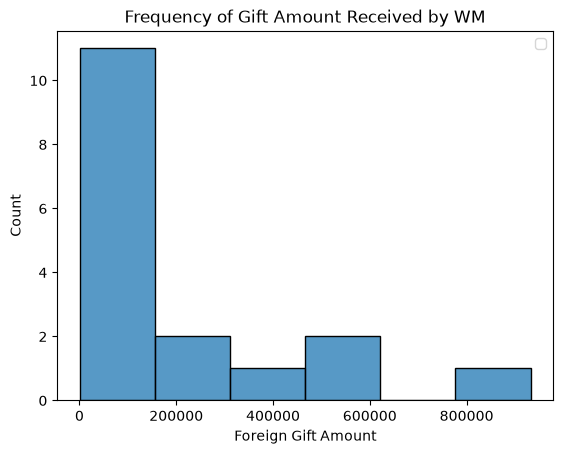

In [12]:
sns.histplot(data=wm_df, x="Foreign Gift Amount")
plt.title("Frequency of Gift Amount Received by WM")
# plt.axvline(x=avg, linestyle="--", label="avg")
# plt.axvline(x=med, label="med")
plt.legend()
plt.show()

C:\Users\kn_mc\AppData\Local\Temp\ipykernel_24656\899696408.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


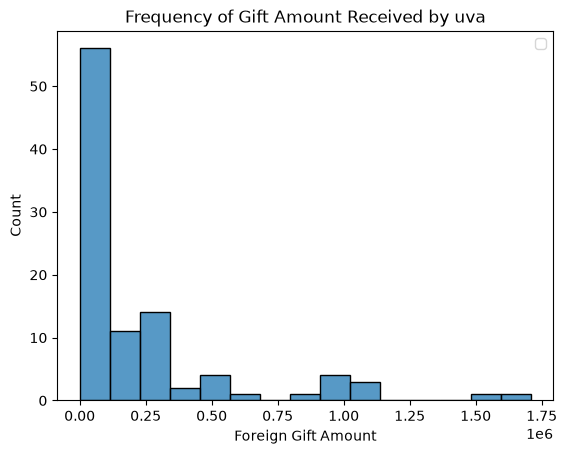

In [13]:
sns.histplot(data=uva_df, x="Foreign Gift Amount")
plt.title("Frequency of Gift Amount Received by uva")
# plt.axvline(x=avg, linestyle="--", label="avg")
# plt.axvline(x=med, label="med")
plt.legend()
plt.show()

C:\Users\kn_mc\AppData\Local\Temp\ipykernel_24656\3747932889.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


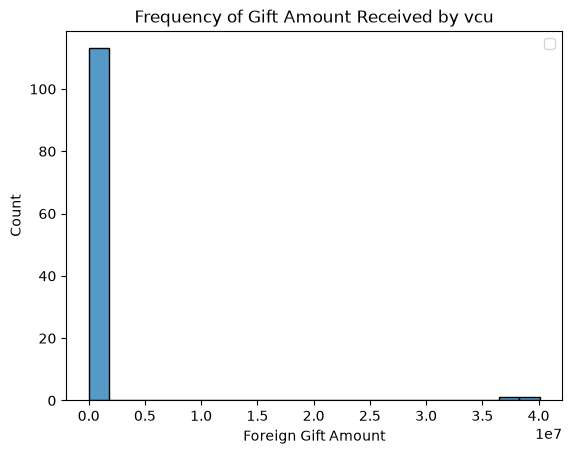

In [14]:
sns.histplot(data=vcu_df, x="Foreign Gift Amount")
plt.title("Frequency of Gift Amount Received by vcu")
# plt.axvline(x=avg, linestyle="--", label="avg")
# plt.axvline(x=med, label="med")
plt.legend()
plt.show()

C:\Users\kn_mc\AppData\Local\Temp\ipykernel_24656\458838871.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


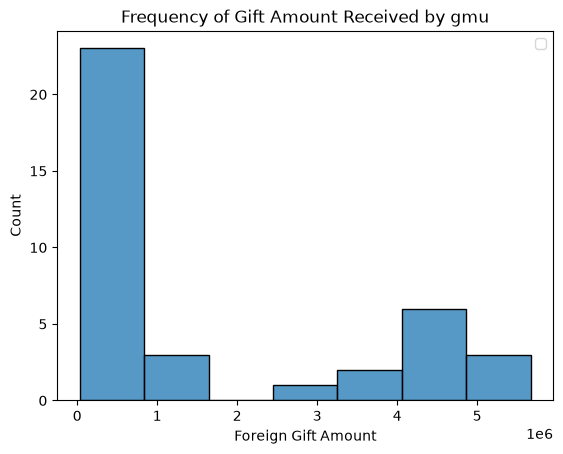

In [15]:
sns.histplot(data=gmu_df, x="Foreign Gift Amount")
plt.title("Frequency of Gift Amount Received by gmu")
# plt.axvline(x=avg, linestyle="--", label="avg")
# plt.axvline(x=med, label="med")
plt.legend()
plt.show()

C:\Users\kn_mc\AppData\Local\Temp\ipykernel_24656\3929592774.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


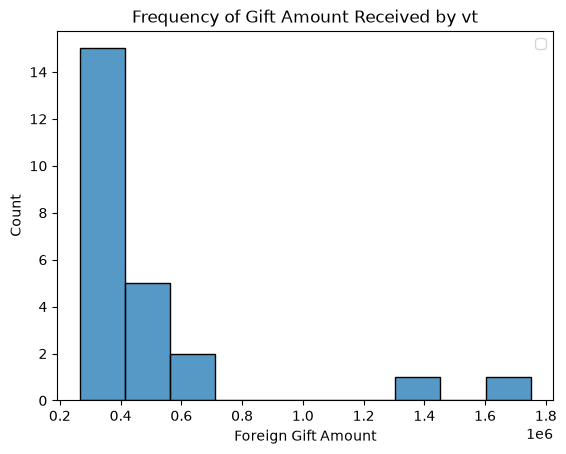

In [16]:
sns.histplot(data=vt_df, x="Foreign Gift Amount")
plt.title("Frequency of Gift Amount Received by vt")
# plt.axvline(x=avg, linestyle="--", label="avg")
# plt.axvline(x=med, label="med")
plt.legend()
plt.show()

Based off the graphs, I see that uva has more middle of the run gift amounts compared to vcu, that has some really large amounts gifted. 

Checking to see what kind of gifts each VA unviersity receives

In [17]:
VA_schools.groupby("Institution Name")["Gift Type"].value_counts()

Institution Name                                   Gift Type    
College of William & Mary                          Monetary Gift     17
George Mason University                            Contract          38
University of Virginia                             Contract          64
                                                   Monetary Gift     34
Virginia Commonwealth University                   Contract         115
Virginia Polytechnic Institute & State University  Contract          24
Name: count, dtype: int64

VT, VCU, and GMU, as well as UVA accept contract type gifts, but UVA also accepts Monetary Gifts as does W&M. UVA is the only school in VA that accepts 2 forms of gifts

Now I want to see some of the top 20 gift types from the total sum, specifically the flow graph

In [18]:
N=25
top_20 = df.groupby(["Country of Giftor","Institution Name"])["Foreign Gift Amount"].sum().nlargest(N).reset_index(name="gift amount")
top_20=pd.DataFrame(top_20)
# top_20.columns
names = top_20["Institution Name"].tolist()
names

['Cornell University',
 'Carnegie Mellon University',
 'Texas A&M University',
 'Carnegie Mellon University',
 'Georgetown University',
 'Northwestern University',
 'Brigham Young University',
 'University of Colorado Boulder',
 'Harvard University',
 'Yale University',
 'University of Phoenix',
 'Northeastern University',
 'Harvard University',
 'Duke University',
 'Massachusetts Institute of Technology',
 'Boston University',
 'Yale University',
 'University of Chicago (The)',
 'Brigham Young University - Idaho',
 'Massachusetts Institute of Technology',
 'Harvard University',
 'Massachusetts Institute of Technology',
 'Virginia Commonwealth University',
 'Yale University',
 'University of Pennsylvania']

In [19]:
df_20 = df[df["Institution Name"].isin(names)]
df_20

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
9993,9994,137000,University of Colorado Boulder,Boulder,CO,41640,282001,Contract,SWEDEN,STOCKHOLM UNIVERSITY
9994,9995,137000,University of Colorado Boulder,Boulder,CO,41640,499246,Contract,MALAYSIA,Malaysia Embassy - PSD
9995,9996,137000,University of Colorado Boulder,Boulder,CO,41640,454526,Contract,UNITED ARAB EMIRATES,UAE-Cultural Division
9996,9997,137000,University of Colorado Boulder,Boulder,CO,41640,2203106,Contract,SAUDI ARABIA,Aramco Services Company
9997,9998,137000,University of Colorado Boulder,Boulder,CO,41640,617608,Contract,OMAN,Oman Embassy Cultural Division
...,...,...,...,...,...,...,...,...,...,...
27938,27939,2098800,University of Phoenix,Phoenix,AZ,42035,250000,Contract,ENGLAND,Taylor & Francis Group
27939,27940,2098800,University of Phoenix,Phoenix,AZ,42248,250000,Contract,ENGLAND,Taylor & Francis Group
27940,27941,2098800,University of Phoenix,Phoenix,AZ,42979,250000,Contract,ENGLAND,Taylor & Francis Group
27941,27942,2098800,University of Phoenix,Phoenix,AZ,43709,250000,Contract,ENGLAND,Taylor & Francis Group


In [20]:
df_20.groupby("Institution Name")["Gift Type"].value_counts()

Institution Name                       Gift Type    
Boston University                      Contract          94
                                       Monetary Gift     31
Brigham Young University               Contract          48
                                       Monetary Gift     14
Brigham Young University - Idaho       Monetary Gift      4
Carnegie Mellon University             Contract         136
                                       Monetary Gift     43
Cornell University                     Contract         404
                                       Monetary Gift    249
Duke University                        Monetary Gift    137
                                       Contract           8
Georgetown University                  Contract          58
                                       Monetary Gift     39
Harvard University                     Contract         235
                                       Monetary Gift    218
Massachusetts Institute of Technology  Monetary

It looks like most in the top 20 accept both gift types

Look at who is donating to uva and who is donating to overall

In [21]:
uva_df.groupby("Giftor Name")["Foreign Gift Amount"].agg(["count", "sum"]).sort_values("sum", ascending=False).head(20)

,count,sum
Giftor Name,,
AstraZeneca,2,3208048
Intrnl Centre Diarrheal Disease,3,1382896
Haydom Lutheran Hospital d/b/a Hayd,1,1100553
Haydom Luther Hospital,1,1035339
Harvest Group Holding,2,1000000
Lawrence D/ Karin S Howell,1,1000000
Lawrence D & Karin S Howell,1,1000000
Danisco Sweeteners Oy,4,990331
Intnl Centre for Diarrhoeal Disease,2,919857


In [22]:
df.groupby("Giftor Name")["Foreign Gift Amount"].agg(["count", "sum"]).sort_values("sum", ascending=False).head(20)

,count,sum
Giftor Name,,
Qatar Foundation,261,1166503744
Qatar Foundation/Qatar National Res,10,796197000
Qatar Foundation for Education,6,373945215
Anonymous,262,338793629
Saudi Arabian Cultural Mission,480,275221475
HCL,5,190000000
Church of Jesus Christ of LDS,7,185203715
Emirates Institute for Advanced Sc,24,170641244
QIC,2,148355497


The top donors to UVA are: AstraZeneca, Intrnl Centre Diarrheal Disease, Haydom Lutheran Hospital d/b/a Hayd, Haydom Luther Hospital, Harvest Group Holding. The top donors in the entire dataset: Qatar Foundation, Qatar Foundation/Qatar National Res, Qatar Foundation for Education, , Anonymous, Saudi Arabian Cultural Mission.

Other schools that are UVA's competitors

In [30]:
# df[df["Institution Name"]== 'University of North Carolina']
# df[df["Institution Name"]== 'University of Michigan']
# df[df["State"]== 'NC'].groupby('Institution Name').value_counts()


Based off the competitor list I found, most of the competitors are in VA, or not in the dataset.

In [35]:
df.groupby("Gift Type")["Foreign Gift Amount"].median()

Gift Type
Contract         110000.0
Monetary Gift     50000.0
Real Estate      667555.0
Name: Foreign Gift Amount, dtype: float64